In [1]:
import pandas as pd
import numpy as np

In [2]:
# Step 1: Read raw data
file_path = 'example_data_usb.txt'
raw_df =pd.read_csv(file_path,header=None)

In [3]:
# Step 2: Extract valid data columns
 # Temporarily store extracted data blocks
all_data_points = []

with open(file_path, 'r') as f:
    lines = f.readlines()

for line in lines:
        # Strip leading and trailing whitespace
        line = line.strip()
        
        # Skip empty lines
        if not line:
            continue
            
        # Split each line by comma
        parts = line.split(',')
        
        try:
            # Format analysis:
            # First 2 columns are Header info: [Timestamp, P] -> indices 0, 1
            # Followed by data blocks in format [C, C, C, C, C, C, C, 0] (7 data + 1 delimiter/auxiliary)
            # Such blocks repeat 1 time per line
            
            # Start index: column 4 (index 3) is the start of the first channel data
            base_index = 2
            
            # Block stride: 7 channel data + 1 separator = 8
            block_stride = 8
            
            # There is 1 sampling block per line (Block)
            
            # Calculate start and end indices of current block
            start = base_index 
            end = start + 7 # We only need the first 7 C values, not the 8th 0
            
            # Extract data for these 7 channels and convert to float
            # parts[start:end] gets the slice
            channel_data = [float(val) for val in parts[start:end]]
            
            # Add the 7 data points at this moment to the total list
            all_data_points.append(channel_data)
            
        except ValueError:
            # Skip lines that cannot be converted to float (e.g., header description lines)
            continue

    # Convert list to NumPy array
    # Shape is now (Total_Samples, 7)
raw_array = np.array(all_data_points)

    # Transpose array to standard signal processing format: (Channel_Num, Data_Points)
    # Final shape becomes (7, Total_Samples)
eeg_data  = raw_array.T    


In [4]:
# 3. Print results for inspection
print(f"Data processing complete.")
print(f"Array type: {type(eeg_data)}")
print(f"Array shape (Channel_num, Data_points): {eeg_data.shape}")
# Print first few data points for verification (e.g., first 10 points of Channel 0)
if eeg_data.size > 0:
    print("\nChannel 0 (First channel)  first 10 data points:")
    print(eeg_data[0, :10])
    
    print("\nChannel 6 (Seventh channel)  first 10 data points:")
    print(eeg_data[6, :10])

Data processing complete.
Array type: <class 'numpy.ndarray'>
Array shape (Channel_num, Data_points): (7, 15113)

Channel 0 (First channel)  first 10 data points:
[62.137848 58.85214  24.22929  15.065075 31.583015 52.616005 52.01251
 27.470293  9.812415 34.98048 ]

Channel 6 (Seventh channel)  first 10 data points:
[25.50334    24.430456    6.258488    0.69290406  4.537404   18.395485
 19.200148    7.554889    0.         10.684134  ]


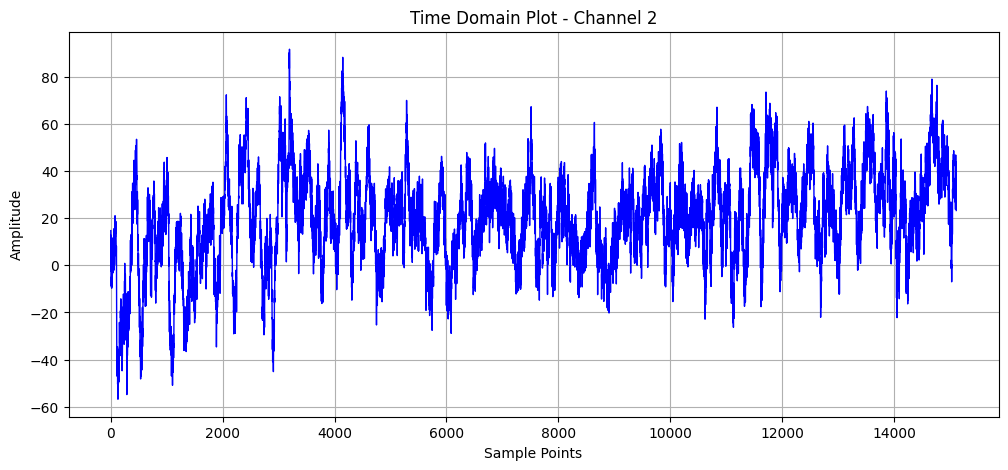

In [5]:
import numpy as np
import matplotlib.pyplot as plt

target_channel = 2 # Select channel index to view (0 to 6)

plt.figure(figsize=(12, 5)) # Set figure size
plt.plot(eeg_data[target_channel, :], color='blue', linewidth=1)
plt.title(f'Time Domain Plot - Channel {target_channel}') # Title
plt.xlabel('Sample Points') # X-axis: sample index
plt.ylabel('Amplitude')     # Y-axis: amplitude
plt.grid(True)              # Show grid
plt.show()                  # Display plot